In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


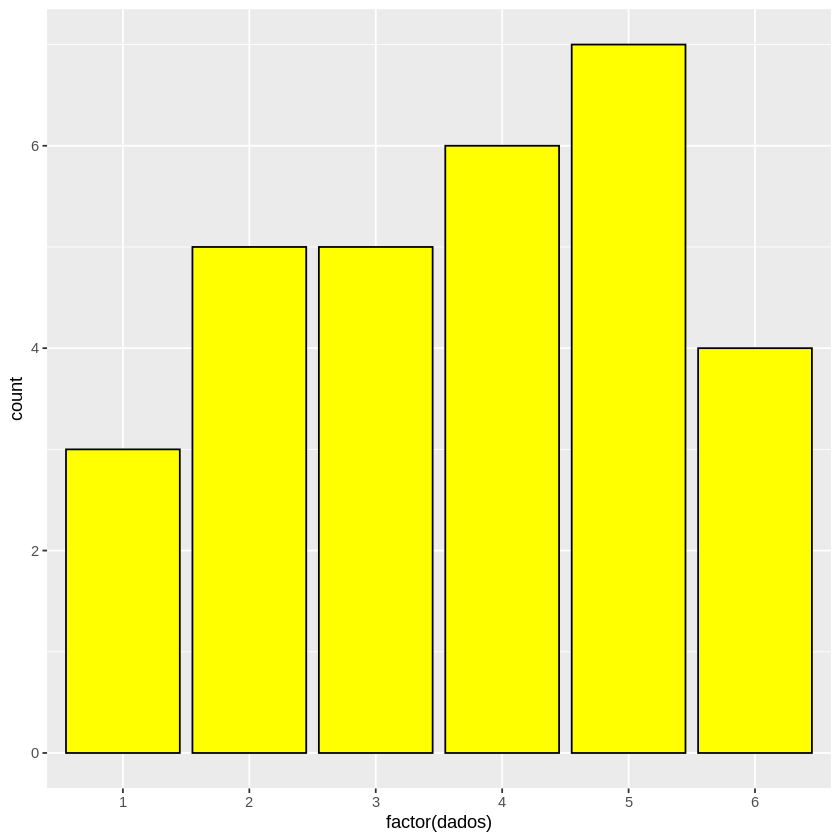

In [44]:
set.seed(2026)
mis_datos = data.frame("dados"=sample(1:6,30,replace=TRUE))

ggplot(data=mis_datos) +
  geom_bar(mapping=aes(x=factor(dados)),color="black",fill="yellow")


In [55]:
### Experimento: lanzar n veces el dado y anotar el promedio
n = 30
N = 365
promedios = colMeans(replicate(N,sample(1:6,n,replace=TRUE)))

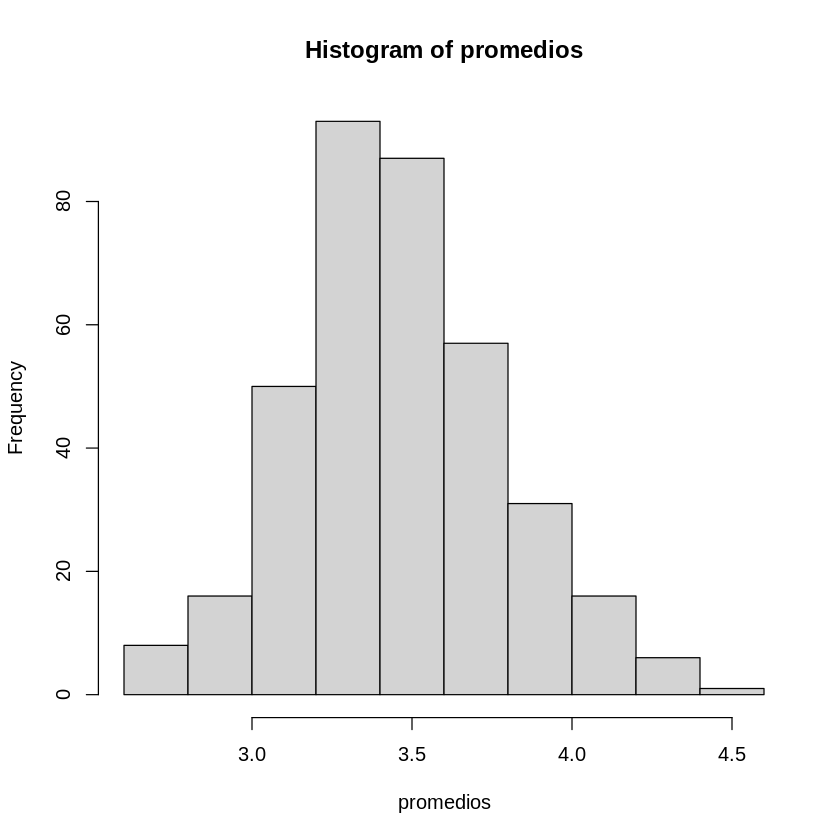

In [56]:
hist(promedios)

In [57]:
alumnos = read_csv("datos_alumnos_con_edad.csv")

Rows: 253 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (3): estatura, edad, sexo

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [58]:
alumnos

estatura,edad,sexo
<dbl>,<dbl>,<dbl>
158,37,1
165,41,0
166,23,1
159,25,0
165,25,1
170,35,1
172,19,1
159,27,0
163,31,1


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


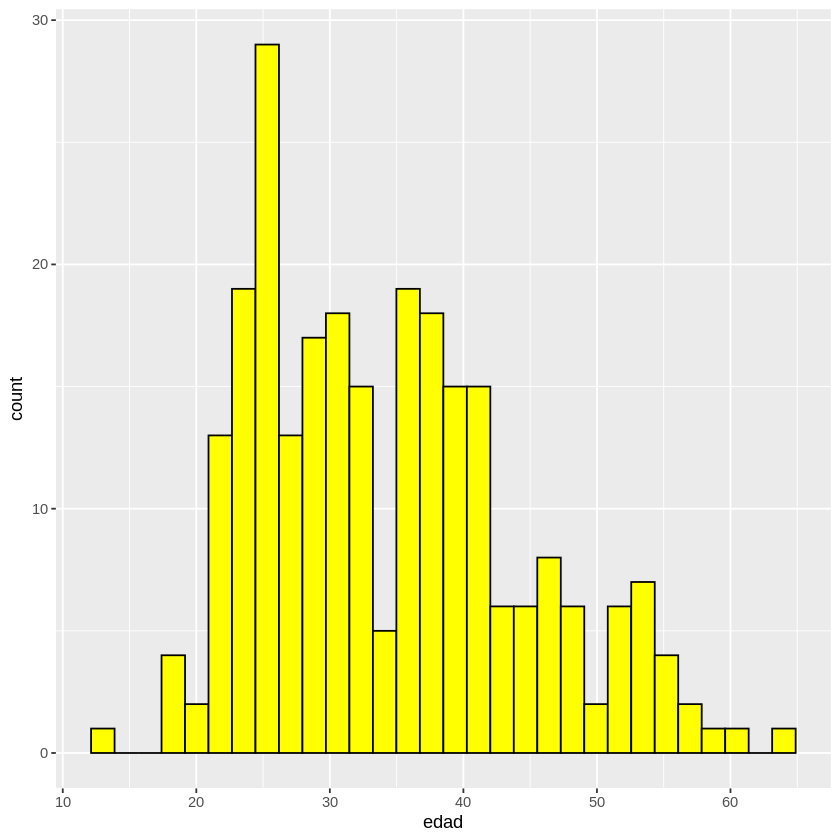

In [61]:
ggplot(data = alumnos) +
  geom_histogram(mapping=aes(x=edad),color="black",fill="yellow")

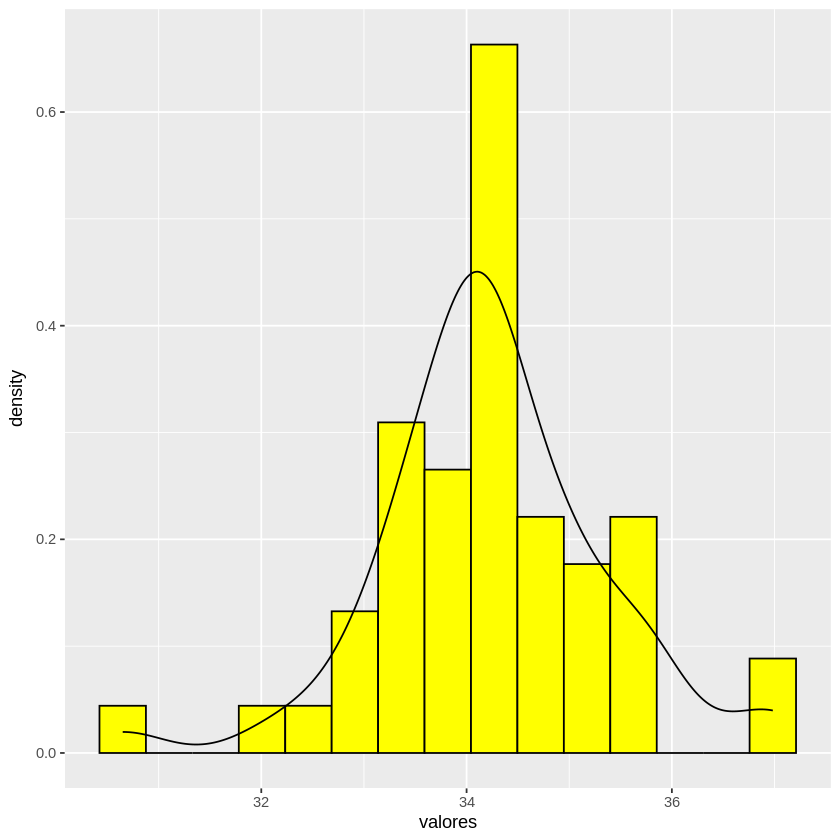

In [75]:
promedio_edades = colMeans(replicate(50,sample(alumnos$edad,60,replace=TRUE)))

tabla_promedio_edades = data.frame("valores"=promedio_edades)

ggplot(data=tabla_promedio_edades) +
  geom_histogram(mapping=aes(x=valores,y=after_stat(density)),bins=15,color="black",fill="yellow") +
  geom_density(mapping=aes(x=valores))


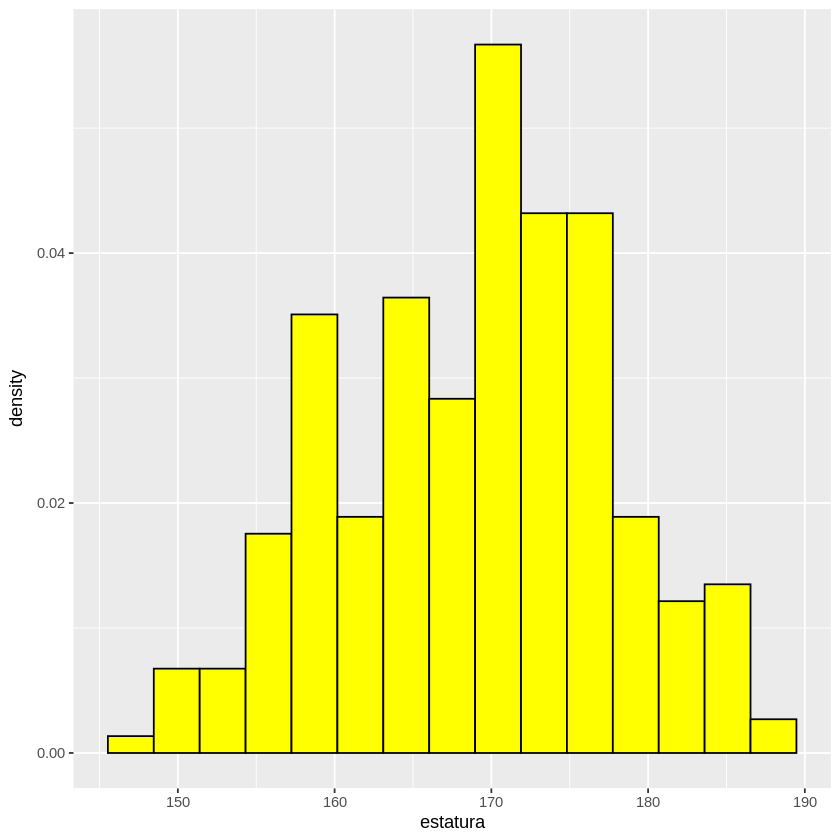

In [80]:
ggplot(data = alumnos) +
  geom_histogram(mapping=aes(x=estatura,y=after_stat(density)),bins=15,color="black",fill="yellow")

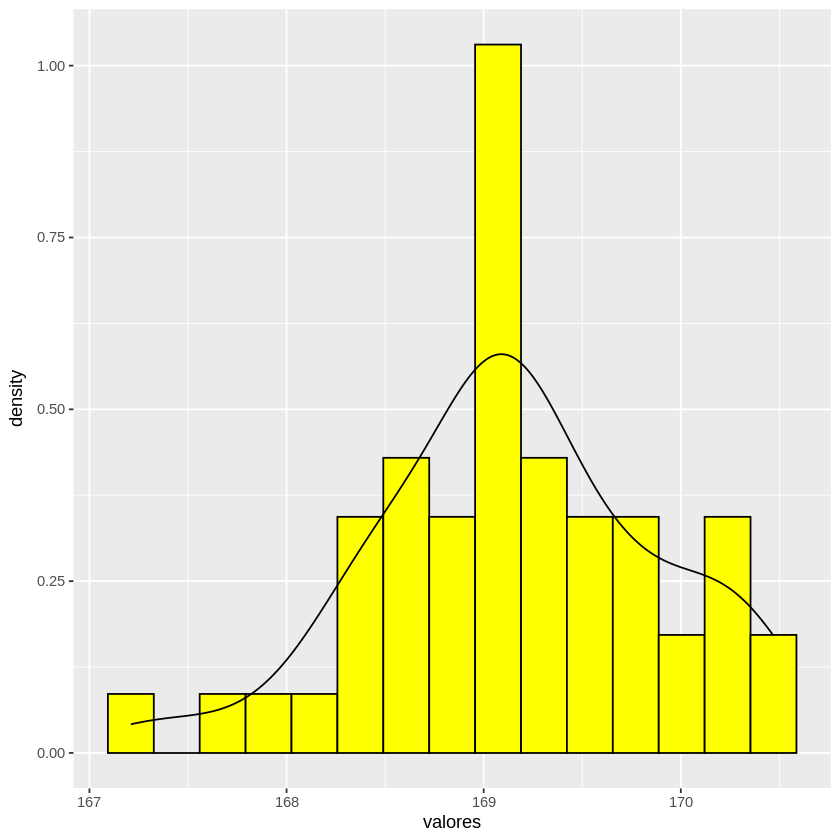

In [82]:
promedio_estatura = colMeans(replicate(50,sample(alumnos$estatura,100,replace=TRUE)))

tabla_promedio_estatura = data.frame("valores"=promedio_estatura)

ggplot(data=tabla_promedio_estatura) +
  geom_histogram(mapping=aes(x=valores,y=after_stat(density)),bins=15,color="black",fill="yellow") +
  geom_density(mapping=aes(x=valores))

In [84]:
media = mean(alumnos$estatura)
desv = sd(alumnos$estatura)

In [85]:
media

[1] 168.9447

In [86]:
desv

[1] 8.322189

In [ ]:
#Ejercicio 1 (Básico) Las estaturas de una población tienen media 170 cm y desviación típica 10 cm. Se toma una muestra de 36 personas.

#¿Cuál es la distribución aproximada de la media muestral?
# Es decir, qué tipo de variable aleatoria es (aproximadamente) (X_1+X_2+...+X_36)/36

# La media es 170 y la sigma=10; por lo tanto sigma^2=100 y así (X_1+X_2+...+X_36)/36 es aproximadamente N(media=170,var=100/36)

In [87]:
# ¿Cuál es la probabilidad de que la media muestral sea menor a 168 cm?
# P((X_1+X_2+...+X_36)/36 < 168)

pnorm(168,170,sqrt(100/36))

[1] 0.1150697

In [88]:
#¿Cuál es la probabilidad de que la media muestral esté entre 168 y 172 cm?
pnorm(172,170,sqrt(100/36)) - pnorm(168,170,sqrt(100/36))

[1] 0.7698607

In [90]:
# ¿Cuál es la media muestral que deja el 90% de las medias por debajo?
qnorm(0.9,170,sqrt(100/36))

[1] 172.1359

In [107]:
# Simula el TLC para una distribución exponencial con λ=1 (media=1, varianza=1).

#Genera 5000 muestras de tamaño n=5, n=30 y n=100.

tabla_exp5 = data.frame("promedios" = colMeans(replicate(1000,rexp(5,1))))
tabla_exp30 = data.frame("promedios" = colMeans(replicate(1000,rexp(30,1))))
tabla_exp100 = data.frame("promedios" = colMeans(replicate(1000,rexp(100,1))))


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


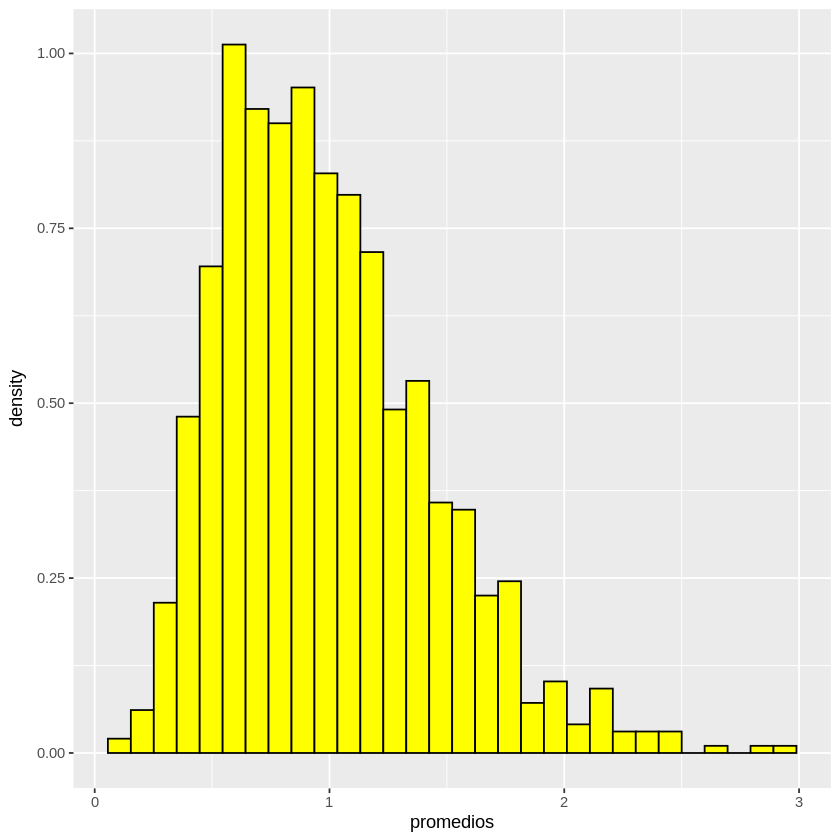

In [108]:
#Para cada n, calcula la media de cada muestra.
#Grafica los histogramas de las medias muestrales.

ggplot(data=tabla_exp5) +
  geom_histogram(mapping=aes(x=promedios,y=after_stat(density)),fill="yellow",color="black")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


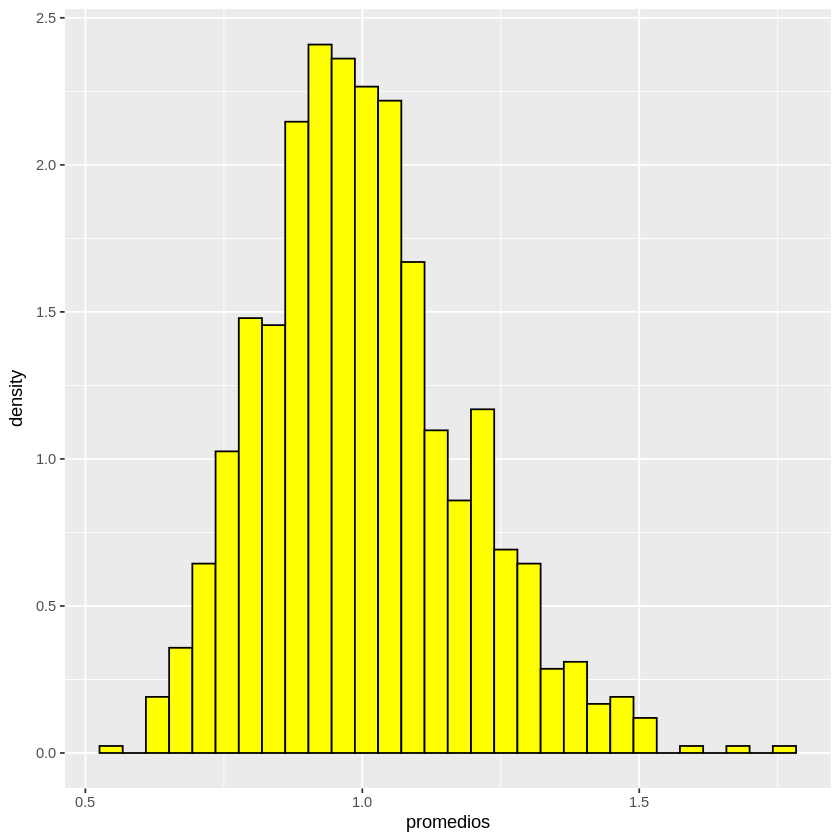

In [109]:
ggplot(data=tabla_exp30) +
  geom_histogram(mapping=aes(x=promedios,y=after_stat(density)),fill="yellow",color="black")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


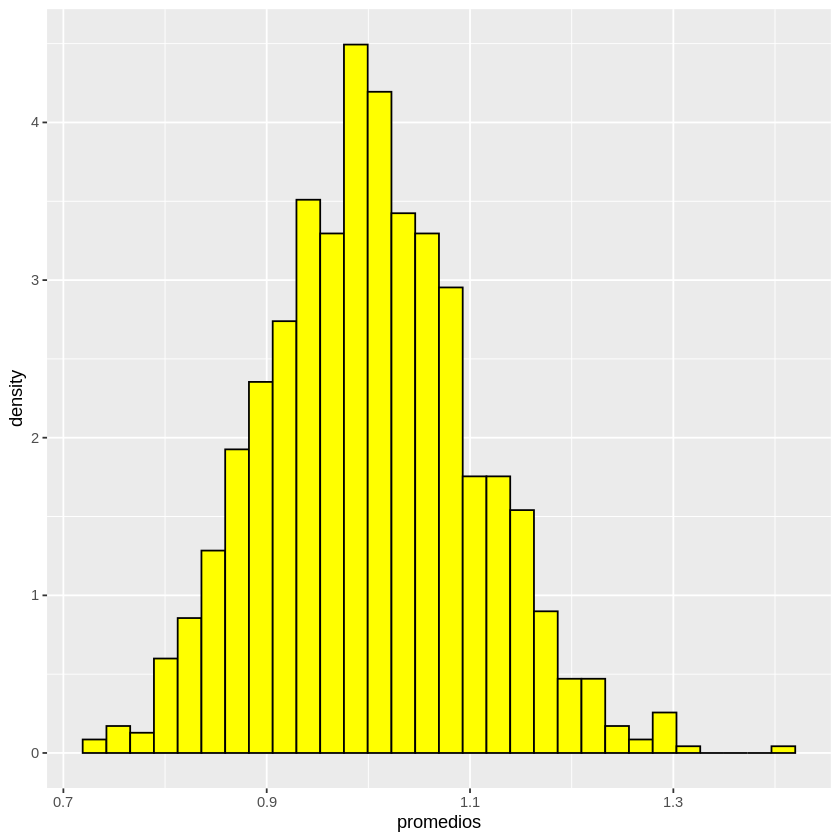

In [110]:
ggplot(data=tabla_exp100) +
  geom_histogram(mapping=aes(x=promedios,y=after_stat(density)),fill="yellow",color="black")

In [111]:
# Ejercicio 4 (Aproximación de la Binomial) En una fábrica, el 40% de los productos son defectuosos. Se toman 200 productos al azar.

# Si no fuera con TLC: Sea X el total de defectuosos, entonces X es Bin(n=200,p=0.4) y me piden P(70<X<90)=P(69<=X<=89)
pbinom(89,200,0.4)-pbinom(69,200,0.4)

[1] 0.8503738

In [113]:
#Usando el TLC, aproxima la probabilidad de que haya entre 70 y 90 defectuosos.
# X_i es una Ber(0.4), i = 1,2,...,200
# S_200 = X_1+X_2+...+X_200
# La media de la población es p y la desviación es sqrt(p(1-p))
# Por lo tanto, para el TLC tenemos media=np=200*0.4 y desviación = sigma*sqrt(n) = sqrt(p(1-p))*sqrt(200)
p = 0.4
sigma = sqrt(p*(1-p))
n = 200

media_tlc = n*p
desv_tlc = sigma*sqrt(n)

pnorm(90,media_tlc,desv_tlc)-pnorm(70,media_tlc,desv_tlc)



[1] 0.8510853

In [ ]:
Compara con el valor exacto usando la distribución Binomial.
¿Se cumplen las condiciones para usar la aproximación Normal?